In [22]:
from matplotlib import pyplot as plt
import numpy as np
# from linReg import *
import csv

X,Y = [],[]

In [23]:

with open('binary.csv', mode='r') as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        X.append([1,int(row["gre"]),float(row["gpa"])])
        Y.append(int(row["admit"]))


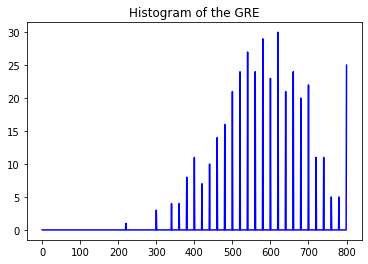

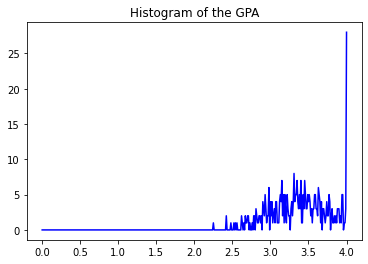

In [3]:
def countOccGRE(b):
    B = dict()
    for i in range(801):
        B[i] = 0

    for row in b:
        B[row] += 1
    
    return B

def countOccGPA(b):
    B = dict()
    for i in range(401):
        B[i] = 0

    for row in b:
        B[int(row*100)] += 1
    
    return B

# function that plots the histogram of an image
def histGRE(b):
    B = countOccGRE(b)
    plt.plot(B.keys(),B.values(),color="blue")
    plt.title("Histogram of the GRE")
    plt.show()

def histGPA(b):
    B = countOccGPA(b)
    B0 = [float(x/100) for x in B.keys()]
    plt.plot(B0,B.values(),color="blue")
    plt.title("Histogram of the GPA")
    plt.show()

Z = [x[0] for x in X]
T = [x[1] for x in X]
histGRE(Z)
histGPA(T)

In [110]:
# def sigmoid(z):
#     return 1 / (1 + np.exp(-z))

# def lossfunction(x, y, w):
#     som = 0
#     m = len(x)
#     for i in range(m):
#          som += np.log(1 + np.exp(-y[i]*(np.dot(w, x[i]))))
#     return som/m

# def gradient(x, y, w):
#     som = 0
#     m = len(x)
#     for i in range(m):
#         # print("w=",w,"x(i)=",x[i])
#         t1 = (-y[i] * np.exp(-y[i] * np.dot(w, x[i])))
#         t2 = 1/(1 + np.exp(-y[i] * np.dot(w, x[i])))
#         # print("t1=",t1,"t2=",t2)
#         som += np.linalg.norm(np.dot((t1 * t2), x[i]))
#     return som/m

# def RergessionLogistic(x, targets, w):
#     compteur = 0 #initialisation de compteur
#     learning_rate = 0.001
#     gradloss = gradient(x, targets, w)
#     while(gradloss > 0.001):
#         #update gradient
#         w =  w - learning_rate *  gradloss
#         gradloss = gradient(x, targets, w)
#         compteur+=1
#     loss = lossfunction(x, targets, w)
#     print(loss)
#     print("le nombre des iterations est : ", compteur)
#     return w

In [33]:
w = [0, 0, 0]
theta = RergessionLogistic(X, Y, w)

inf
le nombre des iterations est :  5


C:\Users\HP\AppData\Local\Temp\ipykernel_1232\3549527601.py:16: RuntimeWarning: overflow encountered in exp
  t1 = (-y[i] * np.exp(-y[i] * np.dot(w, x[i])))
C:\Users\HP\AppData\Local\Temp\ipykernel_1232\3549527601.py:17: RuntimeWarning: overflow encountered in exp
  t2 = 1/(1 + np.exp(-y[i] * np.dot(w, x[i])))
C:\Users\HP\AppData\Local\Temp\ipykernel_1232\3549527601.py:19: RuntimeWarning: invalid value encountered in double_scalars
  som += np.linalg.norm(np.dot((t1 * t2), x[i]))
C:\Users\HP\AppData\Local\Temp\ipykernel_1232\3549527601.py:8: RuntimeWarning: overflow encountered in exp
  som += np.log(1 + np.exp(-y[i]*(np.dot(w, x[i]))))


In [131]:
import numpy as np

# sigmpid activation function
def sigmoid(x):
    '''
    x: a vector
    '''
    return 1/(1 + np.exp(x))

# cost function of the logistic regression for a vector
def costLogReg(x,y,w):
    """
    x: a vector x_i
    y: the label y_i associated
    w: weight vector
    """
    return np.log(1 + np.exp(-y * np.dot(w,x)))

# cost function of the logistic regression for a dataset of vectors
def Cost(X,Y,w):
    return sum([costLogReg(X[i], Y[i], w) for i in range(len(X))])/len(X)

# gradient of cost function for a vector
def gradCost(X,Y,h,w):
    """
    x: a vector x_i
    y: the label y_i associated
    w: weight vector
    h: activation function
    """
    grad = []
    d = len(w)
    m = len(X)
    for i in range(d):
        s = 0
        for j in range(m):
            theta = h(- Y[j] * np.dot(np.array(w).T,X[j]))
            prod = np.dot(Y[i], X[j][i])
            s += prod * theta
        grad.append(s/m)
    return grad

# logistic regression algorithm
def RergessionLogistic(X,Y,h,w):
    compteur = 0 #initialisation de compteur
    lr = 0.1
    loss = gradCost(X,Y,h,w)
    print(loss)
    while(np.linalg.norm(loss) > 0.01):
        print(loss, w)
        #update gradient
        for i in range(len(w)):
            w[i] -= lr * loss[i]
        loss = gradCost(X,Y,h,w)
        compteur += 1
    loss = Cost(X,Y,w)
    print(loss)
    print("le nombre des iterations est : ", compteur)
    return w

In [132]:
w = [1.0, 2.0, 500.0]
theta = RergessionLogistic(X, Y, sigmoid, w)

[0.0, 392.1, 2.248862500000001]
[0.0, 392.1, 2.248862500000001] [1.0, 2.0, 500.0]
[0.0, 195.6, 1.1410374999999993] [1.0, -37.21000000000001, 499.77511375]
[0.0, 195.6, 1.1410374999999993] [1.0, -56.77000000000001, 499.66101]
[0.0, 195.6, 1.1410374999999993] [1.0, -76.33000000000001, 499.54690624999995]


C:\Users\HP\AppData\Local\Temp\ipykernel_1232\1726746304.py:8: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(x))


[0.0, 195.6, 1.1410374999999993] [1.0, -95.89000000000001, 499.4328024999999]
[0.0, 195.6, 1.1410374999999993] [1.0, -115.45000000000002, 499.3186987499999]
[0.0, 195.6, 1.1410374999999993] [1.0, -135.01000000000002, 499.20459499999987]
[0.0, 195.6, 1.1410374999999993] [1.0, -154.57000000000002, 499.09049124999984]
[0.0, 195.6, 1.1410374999999993] [1.0, -174.13000000000002, 498.9763874999998]
[0.0, 195.6, 1.1410374999999993] [1.0, -193.69000000000003, 498.8622837499998]
[0.0, 195.6, 1.1410374999999993] [1.0, -213.25000000000003, 498.74817999999976]
[0.0, 195.6, 1.1410374999999993] [1.0, -232.81000000000003, 498.63407624999974]
[0.0, 195.6, 1.1410374999999993] [1.0, -252.37000000000003, 498.5199724999997]
[0.0, 195.6, 1.1410374999999993] [1.0, -271.93000000000006, 498.4058687499997]
[0.0, 195.6, 1.1410374999999993] [1.0, -291.49000000000007, 498.29176499999966]
[0.0, 195.6, 1.1410374999999993] [1.0, -311.05000000000007, 498.17766124999963]
[0.0, 195.6, 1.1410374999999993] [1.0, -330.610

KeyboardInterrupt: 

w* =  [0.00015875, 0.09825, 0.0005539124999999998]


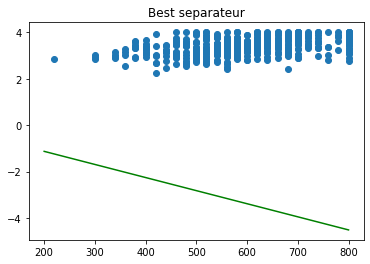

In [109]:
x1, x2 = [e[1] for e in X], [e[2] for e in X]
# print(x1, x2)
plt.scatter(x1, x2)
print('w* = ', theta)
if ( theta[1]!= 0 ):
    t = np.linspace(200, 800, 100)
    z = (-theta[0] - theta[2] * t)/theta[1]
    plt.title('Best separateur')
    plt.plot(t, z, color='green')

In [ ]:
def LogRegTaiwan(S, w, Tmax, hyperplan, viz_mode, visualize = False, save = False):
    '''
    S: the dataset, composed of tuples (xi,yi)
    w: initial weight vector
    Tmax: upper bound of the iterations of the pocket algorithm 
    hyperplan: the equation of the hyperplan to find
    viz_mode: either "2d" or "3d"
    vizualize: turn True to plot the hyperplan and the data, False by default
    save: turn True to save return also a list of the intermediate PLA results
    '''
    t_list = []
    conv_list = []
    w_list=[]
    t = 0
    w0 = np.array(w)
    n = len(S)
    conv = Ls(S,w,n)
    while t < Tmax and conv:
        for i in range(n):
            if np.sign(w.T @ S[i][0]) * S[i][1] < 0:
                for j in range(len(w)):
                    w[j][0] += S[i][1] * S[i][0][j]
        t += 1
        conv = Ls(S,w,n)
        if save : saveIterations(w_list, t_list, conv_list, w0, t, conv)
        if Ls(S, w0, len(S)) > Ls(S, w, len(S)) : w0 = w
    if visualize : generateGraph(S, w0, hyperplan, mode = viz_mode)
    if save : return (w0, Ls(S, w0, len(S)), t, t_list, conv_list, w_list)
    else : return (w0, Ls(S, w0, len(S)), t)